In [1]:
# %%

from pathlib import Path
import sys
import importlib

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.data_loading as exio
import src.analysis_tools as at
import seaborn as sns
import importlib
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
import seaborn as sns
import src.stimuli_timeline as st
import src.plotting as plott
import src.data_loading as exio
import src.analysis_tools as at


In [2]:
import sys
print(sys.version)
print(sys.executable)

3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]
c:\ProgramData\miniconda3\envs\social_filters\python.exe


In [68]:
# %%
### ==== CONFIG GENERAL (común a todos los peces) ===============================

experiment_name = "Exp_5_map_positions"#"Exp_2_rocking_1" #"Exp_3_rocking_2"
main_path = Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p")
analysis_path= Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis")
stimuli_main_path = analysis_path
save_path= analysis_path / experiment_name / "plots"

fps_2p = 2.0
selected_blocks = [f"B{n}" for n in range(1, 5)]

t_pre_s  = 5.0   # time before onset to include
t_post_s = 32.0  # time after onset to include

# Lista de peces que quieres procesar
fish_ids = [
    "L684_f01",
    "L684_f06",
    "L684_f07",
    "L733_f01",
    "L733_f02",
    "L733_f03",
    "L733_f04",
    "L733_f05",
    "L733_f06",
    "L733_f07"    

]

importlib.reload(exio)
importlib.reload(at)

def load_and_align_one_fish(
    fish_id: str,
    experiment_name: str,
    main_path: Path,
    stimuli_main_path: Path,
    fps_2p: float,
    selected_blocks,
    t_pre_s: float,
    t_post_s: float,
):
    """Carga un experimento de un pez y calcula las trial-aligned traces.
    Devuelve TODO lo que quieres para usar después.
    """
    # ==== LOAD EVERYTHING IN ONE GO =========================================
    results = exio.load_2p_experiment(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
    )

    dfof              = results["dfof"]
    stimuli_trace_60  = results["stimuli_trace_60"]
    stimuli_id_map    = results["stimuli_id_map"]
    raster            = results["raster"]
    dfof_center       =results["deltaF_center"]
    dFoF_merged_map    =   results["dFoF_merged_map"]
    stimuli_durations = results["stimuli_durations"]
    kept_neuron_indices = results["kept_neuron_indices"]
    z_traces = results["z_traces"]

        # NEW: normalizar dfof_center a [0, 1] globalmente
    min_val = np.nanmin(dfof_center)          # NEW
    max_val = np.nanmax(dfof_center)          # NEW
    rng = max_val - min_val + 1e-12           # NEW (evita división por cero)

    dfof_center_norm = (dfof_center - min_val) / rng   # NEW


    # ==== BUILD TRIAL-ALIGNED TRACES ========================================
    res = at.build_trial_aligned_traces(
        dfof=dfof,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED TRACES Signf========================================
    res_raster = at.build_trial_aligned_traces(
        dfof=raster,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    ##==== BUILD TRIAL-ALIGNED Norm_Df/F========================================

    res_norm = at.build_trial_aligned_traces(
        dfof=dfof_center_norm,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED Z-core =======================================
    res_zcore = at.build_trial_aligned_traces(
        dfof=z_traces,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    return {
        "trial_aligned_traces": res["trial_aligned_traces"],  # dict: stim_id -> (n_neurons, n_trials, frames)
        "stimuli_ids":          res["stimuli_ids"],           # list
        "stimuli_names":        res["stimuli_names"],         # list
        "win_length":           res["win_length"],            # int
        "stimuli_trace":        res["stimuli_trace"],         # (n_frames_total,)
        "onsets_by_id":         res["onsets_by_id"],          # dict: stim_id -> (n_trials,)
        "trial_aligned_traces_raster": res_raster["trial_aligned_traces"],
        "trial_aligned_traces_norm": res_norm["trial_aligned_traces"],
        "trial_aligned_traces_z_core": res_zcore["trial_aligned_traces"],

        # row data
        "dfof":                  dfof,
        "raster":                raster,
        "dfof_center":           dfof_center,
        "dFoF_merged_map":       dFoF_merged_map,
        "stimuli_durations":     stimuli_durations,
        "kept_neuron_indices":   kept_neuron_indices,
        "stimuli_id_map":         stimuli_id_map,
        # si más tarde quieres acceder a cosas del results original:
        "meta": {
            "frames_per_block":       results["frames_per_block"],
            "duration_2p_block_sec":  results["duration_2p_block_sec"],
            "paths":                  results["paths"],
            "plane_ids":              results["plane_ids"],
            "stat_per_plane":         results["stat_per_plane"],
            # etc, añade aquí lo que te haga falta
        }
    }


# ==== PROCESAR TODOS LOS PECES ==============================================
all_fish_data = {}

for fish_id in fish_ids:
    print(f"\n=== Procesando pez {fish_id} ===")
    all_fish_data[fish_id] = load_and_align_one_fish(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
    )

print("Listo, todos los peces procesados.")



=== Procesando pez L684_f01 ===
Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\significant_traces\L684_f01_significant_traces.npz
Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\filtered_neurons_by_stimuli\L684_f01_kept_neuron_indices.npy
Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\suite2P\merged_dFoF\L684_f01_dFoF_merged_filtered_roi_indices.npy
Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\z_core\L684_f01_zcore.npz
Using canonical merged map file: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\suite2P\merged_

TypeError: unsupported operand type(s) for -: 'NoneType' and 'NoneType'

In [3]:
# %%
### ==== CONFIG GENERAL (común a todos los peces) ===============================

experiment_name = "Exp_5_map_positions"#"Exp_2_rocking_1" #"Exp_3_rocking_2"
main_path = Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p")
analysis_path= Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis")
stimuli_main_path = analysis_path
save_path= analysis_path / experiment_name / "plots"

fps_2p = 2.0
selected_blocks = [f"B{n}" for n in range(1, 5)]

t_pre_s  = 5.0   # time before onset to include
t_post_s = 25.0  # time after onset to include

# Lista de peces que quieres procesar
fish_ids = [
    "L684_f01",
    "L684_f06",
    "L684_f07",
    "L733_f01",
    "L733_f02",
    "L733_f03",
    "L733_f04",
    "L733_f05",
    "L733_f06",
    "L733_f07"    

]

importlib.reload(exio)
importlib.reload(at)

def load_and_align_one_fish(
    fish_id: str,
    experiment_name: str,
    main_path: Path,
    stimuli_main_path: Path,
    fps_2p: float,
    selected_blocks,
    t_pre_s: float,
    t_post_s: float,
):
    """Carga un experimento de un pez y calcula las trial-aligned traces.
    Devuelve TODO lo que quieres para usar después.
    """
    # ==== LOAD EVERYTHING IN ONE GO =========================================
    results = exio.load_2p_experiment(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
    )

    dfof              = results["dfof"]
    stimuli_trace_60  = results["stimuli_trace_60"]
    stimuli_id_map    = results["stimuli_id_map"]
    raster            = results["raster"]
    dfof_center       =results["deltaF_center"]
    dFoF_merged_map    =   results["dFoF_merged_map"]
    stimuli_durations = results["stimuli_durations"]
    kept_neuron_indices = results["kept_neuron_indices"]
    z_traces = results["z_traces"]

    #     # NEW: normalizar dfof_center a [0, 1] globalmente
    # min_val = np.nanmin(dfof_center)          # NEW
    # max_val = np.nanmax(dfof_center)          # NEW
    # rng = max_val - min_val + 1e-12           # NEW (evita división por cero)

    # dfof_center_norm = (dfof_center - min_val) / rng   # NEW


    # ==== BUILD TRIAL-ALIGNED TRACES ========================================
    res = at.build_trial_aligned_traces(
        dfof=dfof,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # # ==== BUILD TRIAL-ALIGNED TRACES Signf========================================
    # res_raster = at.build_trial_aligned_traces(
    #     dfof=raster,
    #     stimuli_trace_60=stimuli_trace_60,
    #     fps_2p=fps_2p,
    #     t_pre_s=t_pre_s,
    #     t_post_s=t_post_s,
    #     stimuli_id_map=stimuli_id_map,  # or None
    #     verbose=True,
    # )

    ##==== BUILD TRIAL-ALIGNED Norm_Df/F========================================

    # res_norm = at.build_trial_aligned_traces(
    #     dfof=dfof_center_norm,
    #     stimuli_trace_60=stimuli_trace_60,
    #     fps_2p=fps_2p,
    #     t_pre_s=t_pre_s,
    #     t_post_s=t_post_s,
    #     stimuli_id_map=stimuli_id_map,  # or None
    #     verbose=True,
    # )

    # ==== BUILD TRIAL-ALIGNED Z-core =======================================
    res_zcore = at.build_trial_aligned_traces(
        dfof=z_traces,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    return {
        "trial_aligned_traces": res["trial_aligned_traces"],  # dict: stim_id -> (n_neurons, n_trials, frames)
        "stimuli_ids":          res["stimuli_ids"],           # list
        "stimuli_names":        res["stimuli_names"],         # list
        "win_length":           res["win_length"],            # int
        "stimuli_trace":        res["stimuli_trace"],         # (n_frames_total,)
        "onsets_by_id":         res["onsets_by_id"],          # dict: stim_id -> (n_trials,)
        # "trial_aligned_traces_raster": res_raster["trial_aligned_traces"],
        # "trial_aligned_traces_norm": res_norm["trial_aligned_traces"],
        "trial_aligned_traces_z_core": res_zcore["trial_aligned_traces"],

        # row data
        "dfof":                  dfof,
        # "raster":                raster,
        "dfof_center":           dfof_center,
        "dFoF_merged_map":       dFoF_merged_map,
        "stimuli_durations":     stimuli_durations,
        "kept_neuron_indices":   kept_neuron_indices,
        "stimuli_id_map":         stimuli_id_map,
        # si más tarde quieres acceder a cosas del results original:
        "meta": {
            "frames_per_block":       results["frames_per_block"],
            "duration_2p_block_sec":  results["duration_2p_block_sec"],
            "paths":                  results["paths"],
            "plane_ids":              results["plane_ids"],
            "stat_per_plane":         results["stat_per_plane"],
            # etc, añade aquí lo que te haga falta
        }
    }


# ==== PROCESAR TODOS LOS PECES ==============================================
all_fish_data = {}

for fish_id in fish_ids:
    print(f"\n=== Procesando pez {fish_id} ===")
    all_fish_data[fish_id] = load_and_align_one_fish(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
    )

print("Listo, todos los peces procesados.")



=== Procesando pez L684_f01 ===
Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\significant_traces\L684_f01_significant_traces.npz
Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\filtered_neurons_by_stimuli\L684_f01_kept_neuron_indices.npy
Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\suite2P\merged_dFoF\L684_f01_dFoF_merged_filtered_roi_indices.npy
Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\z_core\L684_f01_zcore.npz
Using canonical merged map file: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\suite2P\merged_

In [4]:
# select colors and linestyles for stimuli
# --- Set A (default)

colors_C = {
    'FlickL': sns.color_palette('dark:#404040', 10)[7],
    'FlickR': sns.color_palette('dark:#404040', 10)[7],
    'LeB1': sns.color_palette('Blues', 8)[7],
    'LeB2': sns.color_palette('Greens', as_cmap=True)(0.4),
    'LeB3': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'RiB1': sns.color_palette('Blues', 8)[7],
    'RiB2': sns.color_palette('Greens', as_cmap=True)(0.4),
    'RiB3': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'LeB4': sns.color_palette('Reds', as_cmap=True)(0.9),
    'RiB4': sns.color_palette('Reds', as_cmap=True)(0.9),
    'LeBcontrol': sns.color_palette('Greens', as_cmap=True)(0.9),
    'RiBcontrol': sns.color_palette('Greens', as_cmap=True)(0.9),
    'RockL': sns.color_palette('PuRd', as_cmap=True)(0.6),
    'RockR': sns.color_palette('PuRd', as_cmap=True)(0.6),
}
linestyles_C = {
    'FlickR': '--',
    'RiB1': '--',
    'RiB2': '--',
    'RiB3': '--',
    'RiB4': '--',
    'RiBcontrol': '--',
    'RockR': '--',
}

stimuli_colors = colors_C
stimuli_linestyles = linestyles_C

# --- choose stimulus-aligned windows ---
window_pre = 5  # seconds before stimulus
window_post = 17  # seconds after stimulus

stimuli_ordered = [
    'LeBcontrol',
    'RiBcontrol',
    'LeB1',
    'LeB2',
    'LeB3',
    'LeB4',
    'RiB1',
    'RiB2',
    'RiB3',
    'RiB4',
    'RockL',
    'RockR',
    'FlickL',
    'FlickR'
]
print("Using colors for:", experiment_name)
print(stimuli_linestyles)

Using colors for: Exp_5_map_positions
{'FlickR': '--', 'RiB1': '--', 'RiB2': '--', 'RiB3': '--', 'RiB4': '--', 'RiBcontrol': '--', 'RockR': '--'}


In [81]:
from src.multifish_analysis import describe_matrix_widths

describe_matrix_widths(
    all_fish_data,
    stim_order,
    combine_mode="concat",
    trace_type="zscore",
)


[{'fish_id': 'L684_f01',
  'matrix_width': 1680,
  'stim_shapes': {12: (851, 60, 4),
   8: (851, 60, 4),
   9: (851, 60, 4),
   10: (851, 60, 4),
   11: (851, 60, 4),
   2: (851, 60, 4),
   14: (851, 60, 4)}},
 {'fish_id': 'L684_f06',
  'matrix_width': 1680,
  'stim_shapes': {12: (1150, 60, 4),
   8: (1150, 60, 4),
   9: (1150, 60, 4),
   10: (1150, 60, 4),
   11: (1150, 60, 4),
   2: (1150, 60, 4),
   14: (1150, 60, 4)}},
 {'fish_id': 'L684_f07',
  'matrix_width': 1680,
  'stim_shapes': {12: (539, 60, 4),
   8: (539, 60, 4),
   9: (539, 60, 4),
   10: (539, 60, 4),
   11: (539, 60, 4),
   2: (539, 60, 4),
   14: (539, 60, 4)}},
 {'fish_id': 'L733_f01',
  'matrix_width': 1680,
  'stim_shapes': {12: (1343, 60, 4),
   8: (1343, 60, 4),
   9: (1343, 60, 4),
   10: (1343, 60, 4),
   11: (1343, 60, 4),
   2: (1343, 60, 4),
   14: (1343, 60, 4)}},
 {'fish_id': 'L733_f02',
  'matrix_width': 1680,
  'stim_shapes': {12: (1387, 60, 4),
   8: (1387, 60, 4),
   9: (1387, 60, 4),
   10: (1387, 60, 

In [ ]:
def combine_reps_one_stim(arr, mode="concat"):
    """
    arr: (n_neurons, n_time, n_reps)
    mode: "concat" or "mean"

    Returns:
        if mode == "concat": (n_neurons, n_time * n_reps)
        if mode == "mean":   (n_neurons, n_time)
    """
    assert arr.ndim == 3, "Expected 3D array (neurons, time, reps)"
    n_neurons, n_time, n_reps = arr.shape

    if mode == "concat":
        # (N, T, R) -> (N, R, T) -> (N, R*T)
        arr_swapped = np.swapaxes(arr, 1, 2)          # (n_neurons, n_reps, n_time)
        out = arr_swapped.reshape(n_neurons, n_reps * n_time)
        return out

    elif mode == "mean":
        # average across reps axis
        out = np.nanmean(arr, axis=2)                 # (n_neurons, n_time)
        return out

    else:
        raise ValueError(f"Unknown mode '{mode}', use 'concat' or 'mean'")


def build_matrix_for_fish(trial_aligned_traces,
                          stim_order,
                          kept_neuron_indices=None,
                          combine_mode="concat"):
    """
    trial_aligned_traces: dict[stim_id] -> array (neurons, time, reps)
    stim_order: list with desired stimulus order
    kept_neuron_indices: 1D array/list of neuron indices to keep, or None
    combine_mode: "concat" or "mean"
    """
    blocks = []

    for stim in stim_order:
        # Handle int vs str keys
        if stim in trial_aligned_traces:
            arr = trial_aligned_traces[stim]
        else:
            arr = trial_aligned_traces[str(stim)]

        # 🔴 HERE we apply your kept_neuron_indices
        if kept_neuron_indices is not None:
            arr = arr[kept_neuron_indices, :, :]

        arr_block = combine_reps_one_stim(arr, mode=combine_mode)  # (N, T*reps)
        blocks.append(arr_block)

    # Concatenate horizontally along time
    fish_mat = np.concatenate(blocks, axis=1)   # (N, sum_j T_j * reps_j)
    return fish_mat

def build_matrix_all_fish(
    all_fish_data,
    stim_order,
    fish_ids=None,
    combine_mode="concat",
    trace_type="dfof",
):
    """
    all_fish_data[fish_id][...] -> dict[stim] -> (neurons, time, reps)

    Parameters
    ----------
    all_fish_data : dict
        Per-fish data container.
    stim_order : list
        Stimulus order to use when building the matrix.
    fish_ids : list, optional
        Fish IDs to include. If None, use all fish in all_fish_data.
    combine_mode : str, default="concat"
        Passed to build_matrix_for_fish.
    trace_type : str, default="dfof"
        Which trace representation to use:
        - "dfof"   -> trial_aligned_traces
        - "raster" -> trial_aligned_traces_raster
        - "zscore" -> trial_aligned_traces_z_core

    Returns
    -------
    M_all : np.ndarray
        Shape (sum_neurons_all_fish, total_time)
    """
    if fish_ids is None:
        fish_ids = list(all_fish_data.keys())

    mats = []
    for fid in fish_ids:

        if trace_type == "raster":
            trial_key = "trial_aligned_traces_raster"
            kept_idx = None   # already filtered for raster version

        elif trace_type == "zscore":
            trial_key = "trial_aligned_traces_z_core"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        elif trace_type == "dfof":
            trial_key = "trial_aligned_traces"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        else:
            raise ValueError(
                f"Unknown trace_type={trace_type!r}. "
                "Use 'dfof', 'raster', or 'zscore'."
            )

        trial_aligned_traces = all_fish_data[fid][trial_key]

        M_fish = build_matrix_for_fish(
            trial_aligned_traces=trial_aligned_traces,
            stim_order=stim_order,
            kept_neuron_indices=kept_idx,
            combine_mode=combine_mode,
        )
        mats.append(M_fish)

    M_all = np.vstack(mats)

    return M_all

In [72]:
fish_id = fish_ids[1]
trial_aligned_traces = all_fish_data[fish_id]["trial_aligned_traces"]
stimuli_id_map = all_fish_data[fish_id]["stimuli_id_map"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
stimuli_ids = all_fish_data[fish_id]["stimuli_ids"]
stimuli_names = all_fish_data[fish_id]["stimuli_names"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
onsets_by_id = all_fish_data[fish_id]["onsets_by_id"]
print(stimuli_id_map)

{'FlickL': 1, 'FlickR': 2, 'LeB1': 3, 'LeB2': 4, 'LeB3': 5, 'LeB4': 6, 'LeBcontrol': 7, 'RiB1': 8, 'RiB2': 9, 'RiB3': 10, 'RiB4': 11, 'RiBcontrol': 12, 'RockL': 13, 'RockR': 14}


In [73]:
for fid, fish in all_fish_data.items():
    print(f"\nFish: {fid}")

    trial_aligned_traces = fish["trial_aligned_traces"]

    for stim, arr in trial_aligned_traces.items():
        print(f"  stim {stim}: {arr.shape}")



Fish: L684_f01
  stim 1: (851, 60, 4)
  stim 2: (851, 60, 4)
  stim 3: (851, 60, 4)
  stim 4: (851, 60, 4)
  stim 5: (851, 60, 4)
  stim 6: (851, 60, 4)
  stim 7: (851, 60, 4)
  stim 8: (851, 60, 4)
  stim 9: (851, 60, 4)
  stim 10: (851, 60, 4)
  stim 11: (851, 60, 4)
  stim 12: (851, 60, 4)
  stim 13: (851, 60, 4)
  stim 14: (851, 60, 4)

Fish: L684_f06
  stim 1: (1150, 60, 4)
  stim 2: (1150, 60, 4)
  stim 3: (1150, 60, 4)
  stim 4: (1150, 60, 4)
  stim 5: (1150, 60, 4)
  stim 6: (1150, 60, 4)
  stim 7: (1150, 60, 4)
  stim 8: (1150, 60, 4)
  stim 9: (1150, 60, 4)
  stim 10: (1150, 60, 4)
  stim 11: (1150, 60, 4)
  stim 12: (1150, 60, 4)
  stim 13: (1150, 60, 4)
  stim 14: (1150, 60, 4)

Fish: L684_f07
  stim 1: (539, 60, 4)
  stim 2: (539, 60, 4)
  stim 3: (539, 60, 4)
  stim 4: (539, 60, 4)
  stim 5: (539, 60, 4)
  stim 6: (539, 60, 4)
  stim 7: (539, 60, 4)
  stim 8: (539, 60, 4)
  stim 9: (539, 60, 4)
  stim 10: (539, 60, 4)
  stim 11: (539, 60, 4)
  stim 12: (539, 60, 4)
  sti

In [74]:
trace_type = "zscore"   # or "dfof", "raster"

for fid, fish in all_fish_data.items():
    if trace_type == "raster":
        n_plot_neurons = next(iter(fish["trial_aligned_traces_raster"].values())).shape[0]
    else:
        n_plot_neurons = len(fish["kept_neuron_indices"])

    print(fid, n_plot_neurons)


L684_f01 254
L684_f06 322
L684_f07 163
L733_f01 353
L733_f02 369
L733_f03 319
L733_f04 523
L733_f05 396
L733_f06 485
L733_f07 410


In [75]:
counts = {
    fid: len(fish["kept_neuron_indices"])
    for fid, fish in all_fish_data.items()
}

running_total = 0

for fid, n_neurons in counts.items():
    start_row = running_total
    running_total += n_neurons
    end_row = running_total - 1

    print(
        f"{fid}: {n_neurons} neurons | "
        f"rows {start_row}-{end_row} | "
        f"cumulative total = {running_total}"
    )

print("Final total:", running_total)


L684_f01: 254 neurons | rows 0-253 | cumulative total = 254
L684_f06: 322 neurons | rows 254-575 | cumulative total = 576
L684_f07: 163 neurons | rows 576-738 | cumulative total = 739
L733_f01: 353 neurons | rows 739-1091 | cumulative total = 1092
L733_f02: 369 neurons | rows 1092-1460 | cumulative total = 1461
L733_f03: 319 neurons | rows 1461-1779 | cumulative total = 1780
L733_f04: 523 neurons | rows 1780-2302 | cumulative total = 2303
L733_f05: 396 neurons | rows 2303-2698 | cumulative total = 2699
L733_f06: 485 neurons | rows 2699-3183 | cumulative total = 3184
L733_f07: 410 neurons | rows 3184-3593 | cumulative total = 3594
Final total: 3594


In [6]:
# plot all fish together
#{'FlickL': 1, 'FlickR': 2, 'LeB1': 3, 'LeB2': 4, 'LeB3': 5, 'LeB4': 6, 'LeBcontrol': 7, 'RiB1': 8, 'RiB2': 9, 'RiB3': 10, 'RiB4': 11, 'RiBcontrol': 12, 'RockL': 13, 'RockR': 14}


#stim_order = [7,3,4,5,6,1,13,12,8,9,10,11,2,14]
stim_order = [12,8,9,10,11,2,14]
combine_mode = "mean"  # mean or concat
trace_type =  "zscore" #  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
print("Final matrix shape:", M_all.shape)

# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)
flat_matrix_all_fish = M_all  # (time, neurons) for raster_with_stimuli
fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='unsorted',      # or "pca", "hier", etc,unsorted
    n_clusters=3,
    random_state=0,
    neuron_order=None,       # or pass your own `neuron_order`
    sort_label=None,         # optional label override
    is_binary=False,         # True if you pass a 0/1 significance matrix
    show_mean_trace=True,
    figsize=(12, 8),
    fish_id="all_fish",
    vmax=3,
    vmin=-3,
    
)

save_path.mkdir(parents=True, exist_ok=True)
out_png = save_path / f"{fish_id}_dfof_as_func_of_time_pca.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
print("✅ Saved:", out_png)


NameError: name 'build_matrix_all_fish' is not defined

In [ ]:
# calculate Onset!!!

import matplotlib.pyplot as plt

def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))


def compute_mean_onsets_all_fish(
    all_fish_data,
    fish_ids=None,
    stim_order=None,
    fps_2p=2.0,
    response_window_sec=20.0,
    min_run_sec=2.0,
    min_fraction_trials=0.5,
):
    """
    For each fish and stimulus:
      - run classify_responses_from_raster
      - compute mean onset across neurons
      - compute std and sem across neurons

    Returns
    -------
    df_mean_onset : pd.DataFrame
        Columns:
        - fish_id
        - stim_id
        - mean_onset_sec
        - std_onset_sec
        - sem_onset_sec
        - n_responsive_neurons
    """
    if fish_ids is None:
        fish_ids = list(all_fish_data.keys())

    fish_ids = list(dict.fromkeys(fish_ids))  # remove duplicates, keep order

    if stim_order is None:
        stim_order = all_fish_data[fish_ids[0]]["stimuli_ids"]

    rows = []
    onset_sec_by_id_all = {}
    response_type_by_id_all = {}

    for fid in fish_ids:
        fish = all_fish_data[fid]

        response_type_by_id, onset_sec_by_id = at.classify_responses_from_raster(
            raster=fish["raster"],
            onsets_by_id=fish["onsets_by_id"],
            stimuli_id_map=fish["stimuli_id_map"],
            stimuli_durations=fish["stimuli_durations"],
            fps_2p=fps_2p,
            response_window_sec=response_window_sec,
            min_run_sec=min_run_sec,
            min_fraction_trials=min_fraction_trials,
        )

        onset_sec_by_id_all[fid] = onset_sec_by_id
        response_type_by_id_all[fid] = response_type_by_id

        for stim in stim_order:
            key = stim if stim in onset_sec_by_id else str(stim)
            onset_vec = np.asarray(onset_sec_by_id[key], dtype=float)
            valid = onset_vec[np.isfinite(onset_vec)]

            rows.append({
                "fish_id": fid,
                "stim_id": stim,
                "mean_onset_sec": np.mean(valid) if len(valid) > 0 else np.nan,
                "std_onset_sec": np.std(valid, ddof=1) if len(valid) > 1 else np.nan,
                "sem_onset_sec": sem(valid),
                "n_responsive_neurons": len(valid),
            })

    df_mean_onset = pd.DataFrame(rows)
    return df_mean_onset, onset_sec_by_id_all, response_type_by_id_all


def summarize_across_fish(df_mean_onset, stim_order=None):
    df = df_mean_onset.copy()

    if stim_order is not None:
        df["stim_id"] = pd.Categorical(df["stim_id"], categories=stim_order, ordered=True)

    summary = (
        df.groupby("stim_id", as_index=False)
          .agg(
              mean_onset_across_fish_sec=("mean_onset_sec", "mean"),
              std_across_fish_sec=("mean_onset_sec", lambda x: np.std(x.dropna(), ddof=1) if x.notna().sum() > 1 else np.nan),
              sem_across_fish_sec=("mean_onset_sec", sem),
              n_fish=("mean_onset_sec", lambda x: x.notna().sum()),
          )
    )

    if stim_order is not None:
        summary = summary.sort_values("stim_id")

    return summary


def plot_mean_onset_per_fish(
    df_mean_onset,
    fish_order=None,
    stim_order=None,
    error_type="sem",   # "sem", "std", or None
    save_file=None,
):
    df = df_mean_onset.copy()

    if fish_order is None:
        fish_order = df["fish_id"].drop_duplicates().tolist()
    if stim_order is None:
        stim_order = df["stim_id"].drop_duplicates().tolist()

    df["fish_id"] = pd.Categorical(df["fish_id"], categories=fish_order, ordered=True)
    df["stim_id"] = pd.Categorical(df["stim_id"], categories=stim_order, ordered=True)
    df = df.sort_values(["fish_id", "stim_id"])

    pivot_mean = df.pivot(index="fish_id", columns="stim_id", values="mean_onset_sec")

    if error_type == "sem":
        pivot_err = df.pivot(index="fish_id", columns="stim_id", values="sem_onset_sec")
    elif error_type == "std":
        pivot_err = df.pivot(index="fish_id", columns="stim_id", values="std_onset_sec")
    else:
        pivot_err = None

    pivot_mean = pivot_mean.reindex(index=fish_order, columns=stim_order)
    if pivot_err is not None:
        pivot_err = pivot_err.reindex(index=fish_order, columns=stim_order)

    x = np.arange(len(fish_order))
    n_stims = len(stim_order)
    width = 0.8 / max(n_stims, 1)

    fig, ax = plt.subplots(figsize=(max(2, 1.5 * len(fish_order)), 4))

    for i, stim in enumerate(stim_order):
        xpos = x + (i - (n_stims - 1) / 2) * width
        y = pivot_mean[stim].values
        yerr = pivot_err[stim].values if pivot_err is not None else None

        ax.bar(
            xpos,
            y,
            width,
            yerr=yerr,
            capsize=1,
            label=f"Stim {stim}",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(fish_order, rotation=45, ha="right")
    ax.set_ylabel("Mean onset (s)")
    ax.set_xlabel("Fish")
    ax.set_title("Mean onset per stimulus and fish")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    if save_file is not None:
        fig.savefig(save_file, dpi=300, bbox_inches="tight")

    return fig, ax


def plot_mean_onset_across_fish(
    df_summary,
    stim_order=None,
    error_type="sem",   # "sem", "std", or None
    save_file=None,
):
    df = df_summary.copy()

    if stim_order is None:
        stim_order = df["stim_id"].tolist()

    df["stim_id"] = pd.Categorical(df["stim_id"], categories=stim_order, ordered=True)
    df = df.sort_values("stim_id")

    x = np.arange(len(df))
    y = df["mean_onset_across_fish_sec"].values

    if error_type == "sem":
        yerr = df["sem_across_fish_sec"].values
    elif error_type == "std":
        yerr = df["std_across_fish_sec"].values
    else:
        yerr = None

    fig, ax = plt.subplots(figsize=(2, 2))
    ax.bar(x, y, yerr=yerr, capsize=1)

    ax.set_xticks(x)
    ax.set_xticklabels(df["stim_id"].astype(str).tolist(), rotation=45, ha="right")
    ax.set_xlabel("Stimulus")
    ax.set_ylabel("Mean onset across fish (s)")
    ax.set_title("Average onset per stimulus across fish")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    if save_file is not None:
        fig.savefig(save_file, dpi=300, bbox_inches="tight")

    return fig, ax

In [ ]:
# run for calculate onset

# choose the exact order you want
fish_order = [
    "L684_f01",
    "L684_f06",
    "L684_f07",

]

#{'LBb': 1, 'LBc': 2, 'LBd': 3, 'LB': 4, 'RBb': 5, 'RBc': 6, 'RBd': 7, 'RB': 8}
stim_order = [12]   # example, replace with your real stim IDs

df_mean_onset, onset_sec_by_id_all, response_type_by_id_all = compute_mean_onsets_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_order,
    stim_order=stim_order,
    fps_2p=fps_2p,
    response_window_sec=20.0,
    min_run_sec=2.0,
    min_fraction_trials=0.5,
)

df_mean_per_stim = summarize_across_fish(df_mean_onset, stim_order=stim_order)

C:\Users\larsch-lab\AppData\Local\Temp\ipykernel_32076\3444124691.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("stim_id", as_index=False)


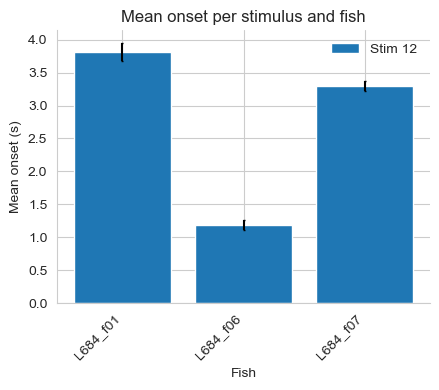

In [ ]:
# plot onset by stimuli per fish

fig1, ax1 = plot_mean_onset_per_fish(
    df_mean_onset,
    fish_order=fish_order,
    stim_order=stim_order,
    error_type="sem",   # or "std" or None
    save_file=save_path / "mean_onset_per_fish_with_errorbars.png",
)

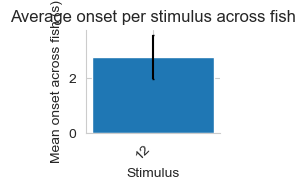

In [ ]:
# plot onset by stimuli avering between fish

fig2, ax2 = plot_mean_onset_across_fish(
    df_mean_per_stim,
    stim_order=stim_order,
    error_type="sem",   # or "std" or None
    save_file=save_path / "mean_onset_across_fish_with_errorbars.png",
)

plt.show()

In [ ]:
## Organize by Left and Rigth response....
## First Concatenate mean traces across experiments
import numpy as np

# result: concat_mean_traces[stim] -> (sum_fish n_kept_neurons_fish, win_length)
concat_mean_traces = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons_norm = {stim: [] for stim in stimuli_ids}

for fid in fish_ids:
    trial_aligned_traces = all_fish_data[fid]["trial_aligned_traces"]
    trial_aligned_traces_norm = all_fish_data[fid]["trial_aligned_traces_z_core"]
    kept_neuron_indices = all_fish_data[fid]["kept_neuron_indices"]

    for stim in stimuli_ids:
        X = trial_aligned_traces[stim]              # (n_neurons, win_length, n_trials)
        Xkept = X[kept_neuron_indices, :, :]        # (n_kept_fish, win_length, n_trials)
        mean_trace = np.nanmean(Xkept, axis=2)     # (n_kept_fish, win_length)
        mean_all_neurons = np.nanmean(mean_trace, axis=0)

        concat_mean_traces[stim].append(mean_trace)
        concat_mean_all_neurons[stim].append(mean_all_neurons)

        Y = trial_aligned_traces_norm[stim]        # same as X but Global Norm
        mean_trace_norm = np.nanmean(Y, axis=2)
        mean_all_neurons_norm = np.nanmean(mean_trace_norm, axis=0)

        concat_mean_all_neurons_norm[stim].append(mean_all_neurons_norm)
# stack per stimulus along the neuron axis
for stim in stimuli_ids:
    concat_mean_traces[stim] = np.vstack(concat_mean_traces[stim])
    concat_mean_all_neurons[stim] = np.vstack(concat_mean_all_neurons[stim])
    concat_mean_all_neurons_norm[stim] = np.vstack(concat_mean_all_neurons_norm[stim])
# Example:
# big_mat_FL1 = concat_mean_traces['FL1']   # shape: (all_kept_neurons_all_fish, win_length)
print(concat_mean_all_neurons[stim].shape)
print(concat_mean_traces[stim].shape)

(3, 74)
(739, 74)


In [ ]:

stim_order = [12,8,9,10,11,2,14]

#stimuli_wanted = [0,1,2,3,4,7,8,9,5,6]  # positions in the list (0-based!)
stimuli_wanted = [11,7,8,9,10,1,13] ## rigth
# stimuli_wanted = [4,1,2,3] ## left
M = {}  # new dict with selected mean_traces
new_stimuli_ids = []  # new list of ids
new_stimuli_names = []  # new list of names

for pos in stimuli_wanted:
    # id in your list at that position
    stim_id = stimuli_ids[pos]
    stim_name = stimuli_names[pos]

    # take the correct array from the dict
    M[stim_id] = concat_mean_all_neurons_norm[stim_id]

    # store id and name in new lists
    new_stimuli_ids.append(stim_id)
    new_stimuli_names.append(stim_name)

print("new_stimuli_ids:  ", new_stimuli_ids)
print("new_stimuli_names:", new_stimuli_names)
# example: check one of the matrices
print("shape of first M:", M[new_stimuli_ids[0]].shape)


fig, ax, used_colors, out_path = plott.plot_stimulus_means(
    mean_traces=M,
    stimuli_ids=new_stimuli_ids,
    stimuli_names=new_stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=t_post_s,
    t_pre_s=t_pre_s,
    stimuli_durations= stimuli_durations,
    plots_path=None,       # Path object or str
    prefix=None,               # e.g., "exp12_mouseA"
    dpi=600,
    save=False,
    stimuli_colors=stimuli_colors,            # <— pass styles here
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells = None,
    comment="jhghjg" # for saving
)



NameError: name 'concat_mean_all_neurons_norm' is not defined